In [1]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.preprocessing import RobustScaler

In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D1 in response_OUS
data = list(OUS_D1['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 

# Merge OUS_D1 with response_OUS
clinical_train = pd.merge(OUS_D1, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS', 'LRC', 'event_LRC'])]

In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D1
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D1['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D1 in response_MAASTRO
data = list(MAASTRO_D1['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D1 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D1, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'DFS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,OS_event
0,1,55,0,0,1,0,0,1,1,1,0,0,15.438583,22.841,263.611623,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,20,1,8.829353,5.660,36.980700,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,6,1,13.476123,7.791,74.636342,44.43,1.0
3,4,61,1,0,0,0,1,1,0,1,45,1,8.632732,7.908,46.791979,37.20,1.0
4,6,70,0,0,1,0,0,1,1,1,59,0,9.783954,15.237,107.637514,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,55,1,31.338410,6.110,144.490782,19.00,1.0
95,111,63,0,0,0,0,1,0,0,1,174,1,13.041604,7.182,69.214868,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,0,1,8.944517,16.483,102.594274,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,0,0,14.184236,9.981,103.229492,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,OS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS'])]

# y 
y = clinical_train.loc[:, ['OS', 'event_OS']]

In [13]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 14)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'OS_event' : 'event_OS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'event_OS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['OS', 'event_OS']]
lower, upper = np.percentile(y_MAASTRO['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_OS'], y_MAASTRO['OS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 16)

# Feature Selection with Random Forest

In [17]:
# Setting y 
y_rsf_classifier = clinical_train['event_OS']

# Define parameters for StratifiedKFold
n_splits = 5
n_repeats = 4

# Initialize variables to store results
all_feature_importances = []

# Perform stratified 5-split 4 times and train Random Forest Classifier for each split
for i in range(n_repeats):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=i)  # Use different random_state for each repeat
    repeat_feature_importances = []
    
    for train_index, test_index in skf.split(X, y_rsf_classifier):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y_rsf_classifier.iloc[train_index], y_rsf_classifier.iloc[test_index]

        # Train Random Forest Classifier
        rf_classifier = RandomForestClassifier(random_state=i)  # You can adjust parameters as needed
        rf_classifier.fit(X_train, y_train)

        # Store feature importances
        repeat_feature_importances.append(rf_classifier.feature_importances_)

    all_feature_importances.append(repeat_feature_importances)

# Convert to numpy array for easier manipulation
all_feature_importances = np.array(all_feature_importances)

# Sum feature importances across repeats and folds
sum_feature_importances = np.sum(all_feature_importances, axis=(0, 1))

# Get feature names
feature_names = list(X)

# Create a DataFrame
df_feature_importances = pd.DataFrame({'Feature': feature_names, 'Importance_Sum': sum_feature_importances})

# Sort feature importances by their sum
df_feature_importances_sorted = df_feature_importances.sort_values(by='Importance_Sum', ascending=False)

RandomForestClassifier(random_state=0)

RandomForestClassifier(random_state=0)

RandomForestClassifier(random_state=0)

RandomForestClassifier(random_state=0)

RandomForestClassifier(random_state=0)

...

RandomForestClassifier(random_state=3)

RandomForestClassifier(random_state=3)

RandomForestClassifier(random_state=3)

RandomForestClassifier(random_state=3)

RandomForestClassifier(random_state=3)

<Figure size 1000x600 with 0 Axes>

<BarContainer object of 14 artists>

Text(0.5, 0, 'Features')

Text(0, 0.5, 'Sum of Absolute Importance Values')

Text(0.5, 1.0, 'Feature Importance using Random Forest Classifier')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

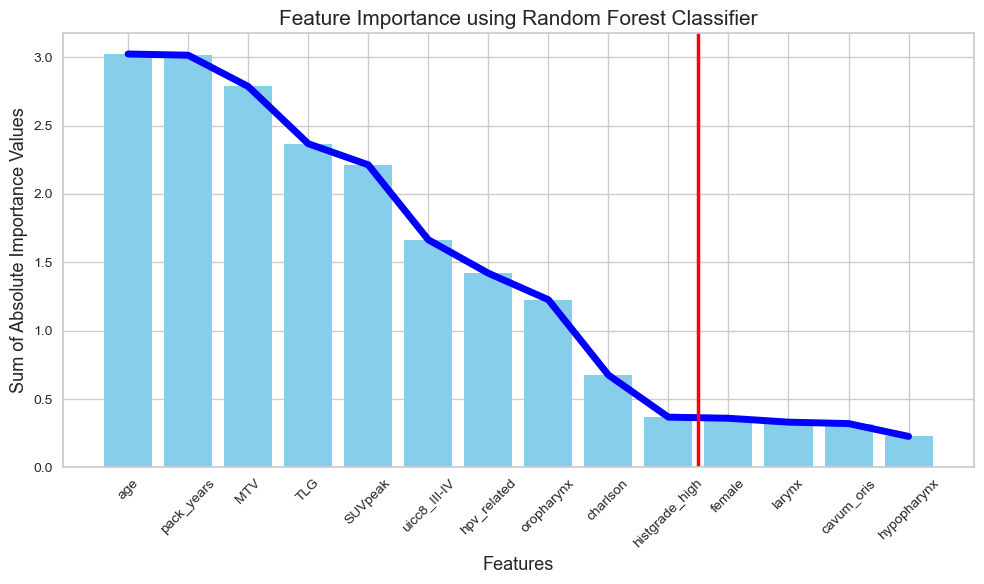

In [20]:
# Plot the bar graph
plt.figure(figsize=(10, 6)) 
plt.bar(df_feature_importances_sorted['Feature'], 
        df_feature_importances_sorted['Importance_Sum'], 
        color='skyblue')
plt.plot(df_feature_importances_sorted['Feature'], 
         df_feature_importances_sorted['Importance_Sum'], 
         color='blue',
        linewidth=5)
plt.xlabel('Features', fontsize=13) 
plt.ylabel('Sum of Absolute Importance Values', fontsize=13) 
plt.title('Feature Importance using Random Forest Classifier', fontsize=15)
plt.xticks(rotation=45) 
plt.axvline(x=9.5, color='red', linestyle='-', linewidth=2.5) 
plt.tight_layout()  
plt.show()

In [21]:
selected_features = df_feature_importances_sorted[0:10]['Feature']

In [22]:
selected_features

0                age
9         pack_years
12               MTV
13               TLG
11           SUVpeak
10      uicc8_III-IV
7        hpv_related
3         oropharynx
8           charlson
6     histgrade_high
Name: Feature, dtype: object

In [23]:
X_rf = X[selected_features]
X_new = X_rf.copy() 

X_MAASTRO_rf = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_rf.copy()

# Standardization

In [24]:
original_X = X.copy()

In [25]:
# Standardize X_new, the new data with the selected features only 
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
scaler = RobustScaler() 
X_new_numeric_columns = X_new_numeric.columns
X_new_numeric_index = X_new_numeric.index 
X_new_numeric_std = scaler.fit_transform(X_new_numeric)
X_new_numeric_std = pd.DataFrame(X_new_numeric_std,
                                 columns=X_new_numeric_columns, 
                                 index=X_new_numeric_index)
X_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]

In [26]:
# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new_std = MAASTRO_new_std[MAASTRO_new.columns]

In [27]:
X_new

,age,pack_years,MTV,TLG,SUVpeak,uicc8_III-IV,hpv_related,oropharynx,charlson,histgrade_high
0,54.238356,0.000000,7.934,86.228420,14.473272,0.0,0.0,1,0,1
1,54.539726,27.404795,1.656,7.040100,5.044678,0.0,0.0,0,1,0
2,59.019178,41.019178,14.502,83.569669,7.839043,1.0,0.0,0,1,1
3,70.726027,37.500000,2.440,5.567091,2.880631,0.0,0.0,0,1,0
4,67.865753,53.000000,3.668,16.150550,5.402006,0.0,0.0,0,1,0
...,...,...,...,...,...,...,...,...,...,...
134,60.435616,0.000000,3.650,26.280140,9.290139,0.0,1.0,1,0,1
135,68.794521,0.000000,18.967,101.754834,7.172883,1.0,1.0,1,0,1
136,57.498630,39.498630,6.370,66.273201,13.873187,0.0,1.0,1,1,1
137,65.684932,71.527397,12.443,71.832443,7.507419,1.0,1.0,1,1,1


In [28]:
X_new_std

,age,pack_years,MTV,TLG,SUVpeak,uicc8_III-IV,hpv_related,oropharynx,charlson,histgrade_high
0,-0.497635,-0.747766,0.075008,0.231096,0.600320,0.0,0.0,1,0,1
1,-0.473435,0.159774,-0.466877,-0.387041,-0.690705,0.0,0.0,0,1,0
2,-0.113739,0.610629,0.641923,0.210342,-0.308082,1.0,0.0,0,1,1
3,0.826312,0.494088,-0.399206,-0.398539,-0.987020,0.0,0.0,0,1,0
4,0.596634,1.007387,-0.293211,-0.315926,-0.641777,0.0,0.0,0,1,0
...,...,...,...,...,...,...,...,...,...,...
134,0.000000,-0.747766,-0.294765,-0.236855,-0.109388,0.0,1.0,1,0,1
135,0.671213,-0.747766,1.027319,0.352293,-0.399297,1.0,1.0,1,0,1
136,-0.235838,0.560275,-0.059989,0.075327,0.518153,0.0,1.0,1,1,1
137,0.421516,1.620942,0.464201,0.118722,-0.353490,1.0,1.0,1,1,1


In [29]:
MAASTRO_new

,age,pack_years,MTV,TLG,SUVpeak,uicc8_III-IV,hpv_related,oropharynx,charlson,histgrade_high
0,55,0,22.841,263.611623,15.438583,0,1,1,1,1
1,55,20,5.660,36.980700,8.829353,1,0,1,0,0
2,55,6,7.791,74.636342,13.476123,1,0,1,1,0
3,61,45,7.908,46.791979,8.632732,1,0,0,1,1
4,70,59,15.237,107.637514,9.783954,0,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...
94,66,55,6.110,144.490782,31.338410,1,0,0,0,0
95,63,174,7.182,69.214868,13.041604,1,0,0,1,0
96,63,0,16.483,102.594274,8.944517,1,1,1,1,1
97,54,0,9.981,103.229492,14.184236,0,1,1,0,1


In [30]:
MAASTRO_new_std

,age,pack_years,MTV,TLG,SUVpeak,uicc8_III-IV,hpv_related,oropharynx,charlson,histgrade_high
0,-0.436476,-0.747766,1.361702,1.615732,0.732497,0,1,1,1,1
1,-0.436476,-0.085444,-0.121272,-0.153327,-0.172482,1,0,1,0,0
2,-0.436476,-0.549070,0.062665,0.140609,0.463784,1,0,1,1,0
3,0.045320,0.742458,0.072763,-0.076742,-0.199405,1,0,0,1,1
4,0.768012,1.206084,0.705364,0.398213,-0.041772,0,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...
94,0.446816,1.073619,-0.082431,0.685886,2.909606,1,0,0,0,0
95,0.205918,5.014436,0.010099,0.098289,0.404287,1,0,0,1,0
96,0.205918,-0.747766,0.812913,0.358846,-0.156713,1,1,1,1,1
97,-0.516775,-0.747766,0.251694,0.363804,0.560744,0,1,1,0,1


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [31]:
# Setting the y format for skf below  
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 23:43:11,614] A new study created in memory with name: no-name-66e603ce-f63e-4de0-bdf1-f2615cef5d48


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.7229437229437229
Fold 2 C-index: 0.7767857142857143
Fold 3 C-index: 0.8186274509803921
Fold 4 C-index: 0.8270042194092827


[I 2024-04-13 23:43:25,576] A new study created in memory with name: no-name-28226e7f-3aa0-4995-880e-34547988e96f


Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:43:25,564] Trial 0 finished with value: 0.7605276205848553 and parameters: {}. Best is trial 0 with value: 0.7605276205848553.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.7605276205848553], datetime_start=datetime.datetime(2024, 4, 13, 23, 43, 11, 717830), datetime_complete=datetime.datetime(2024, 4, 13, 23, 43, 25, 563537), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.7605276205848553


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.1856451490885867
Fold 2 IBS: 0.18524473029686642
Fold 3 IBS: 0.15584670448240048
Fold 4 IBS: 0.1380987659343818
Fold 5 IBS: 0.27557203064084485
[I 2024-04-13 23:43:26,496] Trial 0 finished with value: 0.18808147608861608 and parameters: {}. Best is trial 0 with value: 0.18808147608861608.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.18808147608861608], datetime_start=datetime.datetime(2024, 4, 13, 23, 43, 25, 692559), datetime_complete=datetime.datetime(2024, 4, 13, 23, 43, 26, 495763), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.18808147608861608


In [32]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [33]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.761
train_ibs:  0.188


#### Test

In [34]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [35]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.606
IBS score: 0.291


In [36]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [37]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [38]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 23:43:26,943] A new study created in memory with name: no-name-35dae1bc-87dc-4ae9-bcf8-d6c4c8b0d789


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.5606060606060606
Fold 2 C-index: 0.6763392857142857
Fold 3 C-index: 0.8333333333333334
Fold 4 C-index: 0.8502109704641351
Fold 5 C-index: 0.6197183098591549
[I 2024-04-13 23:43:27,316] Trial 0 finished with value: 0.708041591995394 and parameters: {}. Best is trial 0 with value: 0.708041591995394.


[I 2024-04-13 23:43:27,370] A new study created in memory with name: no-name-9921e667-a03e-4ad8-b568-23e5789f5d64




* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.708041591995394], datetime_start=datetime.datetime(2024, 4, 13, 23, 43, 27, 38435), datetime_complete=datetime.datetime(2024, 4, 13, 23, 43, 27, 316583), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.708041591995394


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.21397652057302996
Fold 2 IBS: 0.22157790931615207
Fold 3 IBS: 0.20453593725187927
Fold 4 IBS: 0.22473802829011877
Fold 5 IBS: 0.21812431395361034
[I 2024-04-13 23:43:27,979] Trial 0 finished with value: 0.2165905418769581 and parameters: {}. Best is trial 0 with value: 0.2165905418769581.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2165905418769581], datetime_start=datetime.datetime(2024, 4, 13, 23, 43, 27, 411436), datetime_complete=datetime.datetime(2024, 4, 13, 23, 43, 27, 979485), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2165905418769581


In [39]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [40]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.708
train_ibs:  0.217


#### Test

In [41]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [42]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.576


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.221


In [43]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [44]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 23:43:28,534] A new study created in memory with name: no-name-65f6dc36-971f-4466-bc2a-05bb949f0e2b


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.7316017316017316
Fold 2 C-index: 0.7857142857142857
Fold 3 C-index: 0.8186274509803921


[I 2024-04-13 23:43:29,394] A new study created in memory with name: no-name-691c46f4-0eb5-4fe1-8f1d-1be946109bf7


Fold 4 C-index: 0.8396624472573839
Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:43:29,371] Trial 0 finished with value: 0.7665765821717915 and parameters: {}. Best is trial 0 with value: 0.7665765821717915.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.7665765821717915], datetime_start=datetime.datetime(2024, 4, 13, 23, 43, 28, 577462), datetime_complete=datetime.datetime(2024, 4, 13, 23, 43, 29, 371091), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.7665765821717915


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.1859022836703002
Fold 2 IBS: 0.18310219356223756
Fold 3 IBS: 0.15508856070470053
Fold 4 IBS: 0.13670827252675186
Fold 5 IBS: 0.2730180573947872
[I 2024-04-13 23:43:30,405] Trial 0 finished with value: 0.18676387357175547 and parameters: {}. Best is trial 0 with value: 0.18676387357175547.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.18676387357175547], datetime_start=datetime.datetime(2024, 4, 13, 23, 43, 29, 431571), datetime_complete=datetime.datetime(2024, 4, 13, 23, 43, 30, 404823), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.18676387357175547


In [45]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [46]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.767
train_ibs:  0.187


#### Test

In [47]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [48]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.609


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.287


In [49]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [50]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 23:43:30,945] A new study created in memory with name: no-name-8db42472-a434-4f58-936b-e03522c6a5fd


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.7316017316017316
Fold 2 C-index: 0.7857142857142857
Fold 3 C-index: 0.8235294117647058
Fold 4 C-index: 0.8396624472573839
Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:43:32,306] Trial 0 finished with value: 0.7675569743286542 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.7675569743286542.
Fold 1 C-index: 0.7272727272727273
Fold 2 C-index: 0.78125
Fold 3 C-index: 0.8235294117647058
Fold 4 C-index: 0.8396624472573839
Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:43:33,631] Trial 1 finished with value: 0.7657983163199963 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.7675569743286542.
Fold 1 C-index: 0.7272727272727273
Fold 2 C-index: 0.78125
Fold 3 C-index: 0.8235294117647058
Fold 4 C-index: 0.8396624472573839
Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:43:34,881] Trial 2 finished with value: 0.7657983163199963 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 0 with 

Fold 1 C-index: 0.7316017316017316
Fold 2 C-index: 0.7857142857142857
Fold 3 C-index: 0.8235294117647058
Fold 4 C-index: 0.8396624472573839
Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:43:58,786] Trial 24 finished with value: 0.7675569743286542 and parameters: {'l1_ratio': 0.7602371709740536}. Best is trial 0 with value: 0.7675569743286542.
Fold 1 C-index: 0.7316017316017316
Fold 2 C-index: 0.7857142857142857
Fold 3 C-index: 0.8235294117647058
Fold 4 C-index: 0.8396624472573839
Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:44:01,137] Trial 25 finished with value: 0.7675569743286542 and parameters: {'l1_ratio': 0.5833004187842314}. Best is trial 0 with value: 0.7675569743286542.
Fold 1 C-index: 0.7316017316017316
Fold 2 C-index: 0.7857142857142857
Fold 3 C-index: 0.8235294117647058
Fold 4 C-index: 0.8396624472573839
Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:44:08,033] Trial 26 finished with value: 0.7675569743286542 and parameters: {'l1_ratio': 0.683379796474269}.

Fold 1 C-index: 0.7316017316017316
Fold 2 C-index: 0.7857142857142857
Fold 3 C-index: 0.8235294117647058
Fold 4 C-index: 0.8396624472573839
Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:44:53,649] Trial 48 finished with value: 0.7675569743286542 and parameters: {'l1_ratio': 0.5683872043393509}. Best is trial 0 with value: 0.7675569743286542.
Fold 1 C-index: 0.7316017316017316
Fold 2 C-index: 0.7857142857142857
Fold 3 C-index: 0.8186274509803921
Fold 4 C-index: 0.8396624472573839
Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:44:55,022] Trial 49 finished with value: 0.7665765821717915 and parameters: {'l1_ratio': 0.9567711086913276}. Best is trial 0 with value: 0.7675569743286542.
Fold 1 C-index: 0.7316017316017316
Fold 2 C-index: 0.7857142857142857
Fold 3 C-index: 0.8235294117647058
Fold 4 C-index: 0.8396624472573839
Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:44:56,022] Trial 50 finished with value: 0.7675569743286542 and parameters: {'l1_ratio': 0.7432829682775339}

...

  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 IBS: 0.1860279024572692
Fold 2 IBS: 0.18335115280926456
Fold 3 IBS: 0.1549870067549246
Fold 4 IBS: 0.1366281176093367
Fold 5 IBS: 0.2726620412705408
[I 2024-04-13 23:45:55,942] Trial 0 finished with value: 0.18673124418026715 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.18673124418026715.
Fold 1 IBS: 0.18625584310357682
Fold 2 IBS: 0.1843303901409581
Fold 3 IBS: 0.15488032772435595
Fold 4 IBS: 0.13660199059359798
Fold 5 IBS: 0.272581436088289
[I 2024-04-13 23:45:57,039] Trial 1 finished with value: 0.18692999753015557 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.18673124418026715.
Fold 1 IBS: 0.1862457541611822
Fold 2 IBS: 0.18456912355964367
Fold 3 IBS: 0.15483304038932527
Fold 4 IBS: 0.1365485529283522
Fold 5 IBS: 0.272399383108991
[I 2024-04-13 23:45:58,332] Trial 2 finished with value: 0.18691917082949888 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 0 with value: 0.18673124418026715.
F

Fold 1 IBS: 0.18594943988602797
Fold 2 IBS: 0.18311029403948567
Fold 3 IBS: 0.15505721196198008
Fold 4 IBS: 0.13671673608450027
Fold 5 IBS: 0.27290258857032373
[I 2024-04-13 23:46:25,021] Trial 25 finished with value: 0.18674725410846355 and parameters: {'l1_ratio': 0.9112329520326179}. Best is trial 21 with value: 0.1867203732041772.
Fold 1 IBS: 0.1860140916017364
Fold 2 IBS: 0.18333364656056148
Fold 3 IBS: 0.15500763913581822
Fold 4 IBS: 0.13661547417318676
Fold 5 IBS: 0.2727319954121797
[I 2024-04-13 23:46:26,260] Trial 26 finished with value: 0.1867405693766965 and parameters: {'l1_ratio': 0.7616995362494663}. Best is trial 21 with value: 0.1867203732041772.
Fold 1 IBS: 0.18593957707655184
Fold 2 IBS: 0.18310390951550834
Fold 3 IBS: 0.15507365522352196
Fold 4 IBS: 0.13673216834458352
Fold 5 IBS: 0.2729695013786766
[I 2024-04-13 23:46:27,595] Trial 27 finished with value: 0.18676376230776842 and parameters: {'l1_ratio': 0.9284980470370928}. Best is trial 21 with value: 0.18672037320

Fold 1 IBS: 0.1859955005978015
Fold 2 IBS: 0.18332918402667286
Fold 3 IBS: 0.15503665841274214
Fold 4 IBS: 0.13665839041912536
Fold 5 IBS: 0.2728518028656052
[I 2024-04-13 23:46:59,267] Trial 50 finished with value: 0.18677430726438943 and parameters: {'l1_ratio': 0.7873751910102478}. Best is trial 21 with value: 0.1867203732041772.
Fold 1 IBS: 0.1859712814071083
Fold 2 IBS: 0.18331872637424185
Fold 3 IBS: 0.15502003882342988
Fold 4 IBS: 0.1367146298481086
Fold 5 IBS: 0.27276847924157105
[I 2024-04-13 23:47:00,629] Trial 51 finished with value: 0.18675863113889193 and parameters: {'l1_ratio': 0.8235070419838388}. Best is trial 21 with value: 0.1867203732041772.
Fold 1 IBS: 0.18595034813080777
Fold 2 IBS: 0.18312576180611292
Fold 3 IBS: 0.15505623950845263
Fold 4 IBS: 0.13663977613340925
Fold 5 IBS: 0.2729160785987701
[I 2024-04-13 23:47:01,964] Trial 52 finished with value: 0.18673764083551053 and parameters: {'l1_ratio': 0.857282243134572}. Best is trial 21 with value: 0.1867203732041

Fold 2 IBS: 0.18333144071047777
Fold 3 IBS: 0.15502792194349277
Fold 4 IBS: 0.13664605109830147
Fold 5 IBS: 0.2728196213948628
[I 2024-04-13 23:47:32,703] Trial 75 finished with value: 0.18676517466262732 and parameters: {'l1_ratio': 0.7798367052880624}. Best is trial 74 with value: 0.18671918776704124.
Fold 1 IBS: 0.18593945584958
Fold 2 IBS: 0.1831038468512344
Fold 3 IBS: 0.15507387475519727
Fold 4 IBS: 0.13673245292543498
Fold 5 IBS: 0.2729703855137661
[I 2024-04-13 23:47:33,836] Trial 76 finished with value: 0.18676400317904257 and parameters: {'l1_ratio': 0.9287141440040761}. Best is trial 74 with value: 0.18671918776704124.
Fold 1 IBS: 0.18590582961348434
Fold 2 IBS: 0.1830858903055654
Fold 3 IBS: 0.15508149991012526
Fold 4 IBS: 0.13669924157643132
Fold 5 IBS: 0.27298968871687057
[I 2024-04-13 23:47:35,029] Trial 77 finished with value: 0.1867524300244954 and parameters: {'l1_ratio': 0.9927651203247123}. Best is trial 74 with value: 0.18671918776704124.
Fold 1 IBS: 0.185953100824

In [51]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [52]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.768
train_ibs:  0.187


#### Test

In [53]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [54]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.6964995386793018)

test_cindex : 0.61


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.88398342365714)

test_ibs:  0.287


In [55]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [56]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 23:48:07,891] A new study created in memory with name: no-name-f41c33c2-f2ed-4d8b-9668-5030f9f0545a


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.7532467532467533
Fold 2 C-index: 0.6339285714285714
Fold 3 C-index: 0.803921568627451
Fold 4 C-index: 0.8544303797468354
Fold 5 C-index: 0.636150234741784
[I 2024-04-13 23:48:18,245] Trial 0 finished with value: 0.7363355015582791 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.7363355015582791.
Fold 1 C-index: 0.7186147186147186
Fold 2 C-index: 0.6696428571428571
Fold 3 C-index: 0.803921568627451
Fold 4 C-index: 0.8523206751054853
Fold 5 C-index: 0.647887323943662
[I 2024-04-13 23:48:28,437] Trial 1 finished with value: 0.7384774286868347 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, 'max

Fold 3 C-index: 0.8333333333333334
Fold 4 C-index: 0.8818565400843882
Fold 5 C-index: 0.704225352112676
[I 2024-04-13 23:50:33,633] Trial 15 finished with value: 0.7926763351493695 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 2, 'min_samples_leaf': 16, 'max_depth': 1, 'n_estimators': 483, 'oob_score': True, 'max_samples': 0.9915936271771615, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.08807762154599924, 'warm_start': True}. Best is trial 15 with value: 0.7926763351493695.
Fold 1 C-index: 0.7489177489177489
Fold 2 C-index: 0.8169642857142857
Fold 3 C-index: 0.8333333333333334
Fold 4 C-index: 0.8818565400843882
Fold 5 C-index: 0.704225352112676
[I 2024-04-13 23:50:41,951] Trial 16 finished with value: 0.7970594520324864 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 2, 'min_samples_leaf': 18, 'max_depth': 1, 'n_estimators': 498, 'oob_score': True, 'max_samples': 0.9632019382250055, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.075649367762977

Fold 1 C-index: 0.7186147186147186
Fold 2 C-index: 0.8392857142857143
Fold 3 C-index: 0.8088235294117647
Fold 4 C-index: 0.8818565400843882
Fold 5 C-index: 0.7183098591549296
[I 2024-04-13 23:51:51,211] Trial 30 finished with value: 0.793378072310303 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 4, 'min_samples_leaf': 13, 'max_depth': 3, 'n_estimators': 85, 'oob_score': True, 'max_samples': 0.8295636627924149, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.03737500582975329, 'warm_start': True}. Best is trial 25 with value: 0.810205399401531.
Fold 1 C-index: 0.7272727272727273
Fold 2 C-index: 0.8303571428571429
Fold 3 C-index: 0.8284313725490197
Fold 4 C-index: 0.8839662447257384
Fold 5 C-index: 0.7089201877934272
[I 2024-04-13 23:51:56,852] Trial 31 finished with value: 0.7957895350396111 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 8, 'min_samples_leaf': 17, 'max_depth': 7, 'n_estimators': 230, 'oob_score': True, 'max_samples': 0.8698146012029154, '

...

Fold 5 IBS: 0.22664902658714126
[I 2024-04-14 00:07:07,579] Trial 31 finished with value: 0.18664402376401593 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 18, 'min_samples_leaf': 4, 'max_depth': 14, 'n_estimators': 293, 'oob_score': False, 'max_samples': 0.760076202384518, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.12053440019786568}. Best is trial 25 with value: 0.18541060533130255.
Fold 1 IBS: 0.17924391428026357
Fold 2 IBS: 0.21580555805224105
Fold 3 IBS: 0.16169962680759295
Fold 4 IBS: 0.1473771359605064
Fold 5 IBS: 0.22270811223488068
[I 2024-04-14 00:07:23,001] Trial 32 finished with value: 0.18536686946709696 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 17, 'min_samples_leaf': 2, 'max_depth': 18, 'n_estimators': 367, 'oob_score': False, 'max_samples': 0.6195244229601323, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.10211517213176136}. Best is trial 32 with value: 0.18536686946709696.
Fold 1 IBS: 0.17986602186177758
Fold 2 IBS: 0.21

Fold 1 IBS: 0.17739465038110155
Fold 2 IBS: 0.21276243506490725
Fold 3 IBS: 0.16160555782186015
Fold 4 IBS: 0.14311242513123648
Fold 5 IBS: 0.22197207125200943
[I 2024-04-14 00:08:50,951] Trial 47 finished with value: 0.18336942793022298 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 11, 'min_samples_leaf': 6, 'max_depth': 9, 'n_estimators': 91, 'oob_score': True, 'max_samples': 0.5030079701115354, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.06742576372903179}. Best is trial 39 with value: 0.18152965851463443.
Fold 1 IBS: 0.17817455766126414
Fold 2 IBS: 0.2056142320761358
Fold 3 IBS: 0.17136980731682958
Fold 4 IBS: 0.1517629787282082
Fold 5 IBS: 0.2158509318926223
[I 2024-04-14 00:08:53,763] Trial 48 finished with value: 0.18455450153501202 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 9, 'min_samples_leaf': 4, 'max_depth': 5, 'n_estimators': 40, 'oob_score': True, 'max_samples': 0.45113067734816487, 'max_features': 'auto', 'min_weight_fraction_leaf

Fold 1 IBS: 0.18021371373261355
Fold 2 IBS: 0.20276408785346708
Fold 3 IBS: 0.1649417152136776
Fold 4 IBS: 0.15142221337436843
Fold 5 IBS: 0.21894260849421615
[I 2024-04-14 00:10:05,997] Trial 63 finished with value: 0.18365686773366857 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 4, 'min_samples_leaf': 10, 'max_depth': 6, 'n_estimators': 96, 'oob_score': True, 'max_samples': 0.595897376295266, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.012492189362659112}. Best is trial 39 with value: 0.18152965851463443.
Fold 1 IBS: 0.17901142015584834
Fold 2 IBS: 0.21784040587874096
Fold 3 IBS: 0.16088565909392738
Fold 4 IBS: 0.14287077029960885
Fold 5 IBS: 0.22469333583962847
[I 2024-04-14 00:10:13,018] Trial 64 finished with value: 0.1850603182535508 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 6, 'min_samples_leaf': 7, 'max_depth': 9, 'n_estimators': 135, 'oob_score': True, 'max_samples': 0.6542957469639504, 'max_features': 'sqrt', 'min_weight_fraction_lea

Fold 1 IBS: 0.1846630295744542
Fold 2 IBS: 0.2094063233794573
Fold 3 IBS: 0.1725928631353916
Fold 4 IBS: 0.16850815329771193
Fold 5 IBS: 0.21861719205278374
[I 2024-04-14 00:31:02,155] Trial 79 finished with value: 0.19075751228795976 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 2, 'min_samples_leaf': 11, 'max_depth': 7, 'n_estimators': 85, 'oob_score': True, 'max_samples': 0.6691101514115952, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.07379564215435265}. Best is trial 39 with value: 0.18152965851463443.
Fold 1 IBS: 0.1806562415271345
Fold 2 IBS: 0.2149229351576256
Fold 3 IBS: 0.1619331641155935
Fold 4 IBS: 0.1482603925846792
Fold 5 IBS: 0.22381820855608095
[I 2024-04-14 00:31:16,662] Trial 80 finished with value: 0.18591818838822274 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 6, 'min_samples_leaf': 9, 'max_depth': 5, 'n_estimators': 193, 'oob_score': True, 'max_samples': 0.575453026455684, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.

Fold 1 IBS: 0.18067051892997218
Fold 2 IBS: 0.20976917694401034
Fold 3 IBS: 0.1627021515583648
Fold 4 IBS: 0.15155219149304505
Fold 5 IBS: 0.22007018815890209
[I 2024-04-14 00:33:06,610] Trial 95 finished with value: 0.1849528454168589 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 5, 'min_samples_leaf': 9, 'max_depth': 7, 'n_estimators': 132, 'oob_score': True, 'max_samples': 0.4847998384701818, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.07698922447900798}. Best is trial 39 with value: 0.18152965851463443.
Fold 1 IBS: 0.17653837850706317
Fold 2 IBS: 0.21665820235713712
Fold 3 IBS: 0.15925978769855675
Fold 4 IBS: 0.1361996911640683
Fold 5 IBS: 0.22133644256987917
[I 2024-04-14 00:33:12,273] Trial 96 finished with value: 0.1819985004593409 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 8, 'min_samples_leaf': 6, 'max_depth': 9, 'n_estimators': 100, 'oob_score': True, 'max_samples': 0.6411081762780679, 'max_features': 'sqrt', 'min_weight_fraction_leaf'

In [57]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [58]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.867
train_ibs:  0.181


#### Test

In [59]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [60]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=13, max_leaf_nodes=12,
                     max_samples=0.8731189968319242, min_samples_leaf=2,
                     min_samples_split=7,
                     min_weight_fraction_leaf=0.012901666963593935,
                     n_estimators=393, random_state=123, warm_start=True)

test_cindex:  0.68


RandomSurvivalForest(max_depth=9, max_leaf_nodes=4,
                     max_samples=0.6434896963800851, min_samples_leaf=6,
                     min_samples_split=16,
                     min_weight_fraction_leaf=0.008689309516786857,
                     n_estimators=93, oob_score=True, random_state=123)

test_ibs:  0.204


In [61]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [62]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 00:33:35,386] A new study created in memory with name: no-name-f52c1e26-c851-4d4d-84e4-709afa47b4c7


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.7186147186147186
Fold 2 C-index: 0.8035714285714286
Fold 3 C-index: 0.8431372549019608
Fold 4 C-index: 0.8523206751054853
Fold 5 C-index: 0.6948356807511737
[I 2024-04-14 00:33:38,399] Trial 0 finished with value: 0.7824959515889536 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.7824959515889536.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 00:33:46,439] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531

Fold 1 C-index: 0.7489177489177489
Fold 2 C-index: 0.7767857142857143
Fold 3 C-index: 0.8333333333333334
Fold 4 C-index: 0.8164556962025317
Fold 5 C-index: 0.6619718309859155
[I 2024-04-14 00:35:34,126] Trial 16 finished with value: 0.7674928647450487 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 20, 'n_estimators': 499, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.6535355702555379, 'min_weight_fraction_leaf': 0.1906011147608997}. Best is trial 12 with value: 0.7926307801682724.
Fold 1 C-index: 0.7727272727272727
Fold 2 C-index: 0.7857142857142857
Fold 3 C-index: 0.8161764705882353
Fold 4 C-index: 0.8164556962025317
Fold 5 C-index: 0.6384976525821596
[I 2024-04-14 00:35:38,528] Trial 17 finished with value: 0.7659142755628969 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 10, 'min_samples_leaf': 8, 'max_depth': 10, 'n_estimators': 384, 'oob_score': False, 'warm_start': True, 'max_featu

Fold 1 C-index: 0.7316017316017316
Fold 2 C-index: 0.8348214285714286
Fold 3 C-index: 0.8578431372549019
Fold 4 C-index: 0.8565400843881856
Fold 5 C-index: 0.7089201877934272
[I 2024-04-14 00:36:54,319] Trial 31 finished with value: 0.797945313921935 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 6, 'min_samples_leaf': 2, 'max_depth': 10, 'n_estimators': 467, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.9286371142434082, 'min_weight_fraction_leaf': 0.043457520259011145}. Best is trial 31 with value: 0.797945313921935.
Fold 1 C-index: 0.7272727272727273
Fold 2 C-index: 0.8392857142857143
Fold 3 C-index: 0.8578431372549019
Fold 4 C-index: 0.8481012658227848
Fold 5 C-index: 0.704225352112676
[I 2024-04-14 00:36:58,825] Trial 32 finished with value: 0.7953456393497609 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 6, 'min_samples_leaf': 2, 'max_depth': 10, 'n_estimators': 412, 'oob_score': False, 'warm_start': True, 'max_feature

...

Fold 1 IBS: 0.1700519965855827
Fold 2 IBS: 0.21054009443018218
Fold 3 IBS: 0.16719925029759086
Fold 4 IBS: 0.1613089358324982
Fold 5 IBS: 0.23161013296531519
[I 2024-04-14 00:47:43,629] Trial 30 finished with value: 0.18814208202223381 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 15, 'min_samples_leaf': 8, 'max_depth': 12, 'n_estimators': 231, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.5014558998220808, 'min_weight_fraction_leaf': 0.07553984363425942}. Best is trial 6 with value: 0.1858169831832369.
Fold 1 IBS: 0.17216923621723923
Fold 2 IBS: 0.2108044066276367
Fold 3 IBS: 0.16702564967756997
Fold 4 IBS: 0.16193700192755658
Fold 5 IBS: 0.22777679864148306
[I 2024-04-14 00:47:47,567] Trial 31 finished with value: 0.18794261861829709 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 8, 'min_samples_leaf': 9, 'max_depth': 5, 'n_estimators': 104, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.50

Fold 1 IBS: 0.17435639182974702
Fold 2 IBS: 0.20994478059366992
Fold 3 IBS: 0.17390642939991824
Fold 4 IBS: 0.15611012586331807
Fold 5 IBS: 0.23484087328723918
[I 2024-04-14 00:48:51,761] Trial 45 finished with value: 0.18983172019477848 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 4, 'min_samples_leaf': 2, 'max_depth': 7, 'n_estimators': 30, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.36358160358674346, 'min_weight_fraction_leaf': 0.019139627806960186}. Best is trial 6 with value: 0.1858169831832369.
Fold 1 IBS: 0.16982796418539936
Fold 2 IBS: 0.2051095587601829
Fold 3 IBS: 0.16744029805038804
Fold 4 IBS: 0.16614272074156763
Fold 5 IBS: 0.2257030535974815
[I 2024-04-14 00:48:54,969] Trial 46 finished with value: 0.1868447190670039 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 7, 'min_samples_leaf': 10, 'max_depth': 2, 'n_estimators': 83, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.52

Fold 1 IBS: 0.16765519376833984
Fold 2 IBS: 0.21338935024041344
Fold 3 IBS: 0.16485157739969006
Fold 4 IBS: 0.15053829791384152
Fold 5 IBS: 0.23475096475779542
[I 2024-04-14 00:50:26,741] Trial 60 finished with value: 0.18623707681601606 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 4, 'min_samples_leaf': 2, 'max_depth': 6, 'n_estimators': 248, 'oob_score': True, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7515269679411078, 'min_weight_fraction_leaf': 0.0331030054971697}. Best is trial 6 with value: 0.1858169831832369.
Fold 1 IBS: 0.1680473256730751
Fold 2 IBS: 0.21133389100118852
Fold 3 IBS: 0.16515345727901012
Fold 4 IBS: 0.15059428998658445
Fold 5 IBS: 0.23565505113617552
[I 2024-04-14 00:50:36,032] Trial 61 finished with value: 0.1861568030152067 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 4, 'min_samples_leaf': 2, 'max_depth': 6, 'n_estimators': 225, 'oob_score': True, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.761016

Fold 1 IBS: 0.17259670656908646
Fold 2 IBS: 0.21818838399873644
Fold 3 IBS: 0.16452180367563315
Fold 4 IBS: 0.15183007751790134
Fold 5 IBS: 0.24105979875791303
[I 2024-04-14 00:52:57,123] Trial 75 finished with value: 0.18963935410385407 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 12, 'min_samples_leaf': 1, 'max_depth': 5, 'n_estimators': 173, 'oob_score': True, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7036897052631409, 'min_weight_fraction_leaf': 0.061934596197347286}. Best is trial 68 with value: 0.18519930021630024.
Fold 1 IBS: 0.17049974316232996
Fold 2 IBS: 0.21021282137570835
Fold 3 IBS: 0.171725346934489
Fold 4 IBS: 0.16993046099944767
Fold 5 IBS: 0.22486721791680528
[I 2024-04-14 00:53:07,167] Trial 76 finished with value: 0.18944711807775605 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 5, 'min_samples_leaf': 12, 'max_depth': 6, 'n_estimators': 214, 'oob_score': True, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.

Fold 1 IBS: 0.1663533549271886
Fold 2 IBS: 0.2150071794842812
Fold 3 IBS: 0.16079786805569013
Fold 4 IBS: 0.14787623402213085
Fold 5 IBS: 0.23479337027361627
[I 2024-04-14 00:54:55,652] Trial 90 finished with value: 0.18496560135258142 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 1, 'max_depth': 10, 'n_estimators': 157, 'oob_score': True, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.8849026790155812, 'min_weight_fraction_leaf': 0.017295283166596138}. Best is trial 90 with value: 0.18496560135258142.
Fold 1 IBS: 0.16759010491213924
Fold 2 IBS: 0.2151914874280737
Fold 3 IBS: 0.1620018099937226
Fold 4 IBS: 0.14877281905345466
Fold 5 IBS: 0.2340529034619089
[I 2024-04-14 00:55:01,910] Trial 91 finished with value: 0.1855218249698598 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 1, 'max_depth': 10, 'n_estimators': 168, 'oob_score': True, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.88399

In [63]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [64]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.814
train_ibs:  0.184


#### Test

In [65]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [66]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=11, max_features=None, max_leaf_nodes=12,
                   max_samples=0.9744075181519277, min_samples_leaf=1,
                   min_samples_split=18,
                   min_weight_fraction_leaf=0.0008190349739849552,
                   n_estimators=306, random_state=123, warm_start=True)

C-index score: 0.613


ExtraSurvivalTrees(max_depth=12, max_features='log2', max_leaf_nodes=5,
                   max_samples=0.9255044252610253, min_samples_leaf=1,
                   min_samples_split=5,
                   min_weight_fraction_leaf=0.014356295713664476,
                   n_estimators=132, oob_score=True, random_state=123,
                   warm_start=True)

IBS: 0.219


In [67]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [68]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-14 00:55:46,492] A new study created in memory with name: no-name-261dbd11-6406-46e6-b99c-645aa142b63f


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 00:56:46,741] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 00:57:20,540] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:13:14,000] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.8386796524426539, 'learning_rate': 0.046734492485875676, 'dropout_rate': 0.4821375662037144, 'n_estimators': 402, 'criterion': 'squared_error', 'ccp_alpha': 1.5696007313501796, 'min_weight_fraction_leaf': 0.18684147934268416, 'max_features': 'log2', 'min_impurity_decrease': 1.5044881127471587e-06, 'validation_fraction': 0.8166356053932342, 'min_samples_split': 16, 'max_leaf_nodes': 19, 'min_samples_leaf': 16, 'max_depth': 4}. Best is trial 9 with value: 0.7334874350516556.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:15:08,446] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.33235389014851724, 'learning_rate': 0.04522573411670834, 'dropout_rate': 0.2712811374536856, 'n_estimators': 405, 'criterion': 'square

Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:34:03,506] Trial 25 finished with value: 0.5 and parameters: {'subsample': 0.7565257046780437, 'learning_rate': 0.01188344684416992, 'dropout_rate': 0.3433523077110169, 'n_estimators': 318, 'criterion': 'squared_error', 'ccp_alpha': 2.063559212730723, 'min_weight_fraction_leaf': 0.25401273903421573, 'max_features': 'auto', 'min_impurity_decrease': 5.773435946665558e-07, 'validation_fraction': 0.8062268184400477, 'min_samples_split': 16, 'max_leaf_nodes': 18, 'min_samples_leaf': 5, 'max_depth': 3}. Best is trial 9 with value: 0.7334874350516556.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5558035714285714
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.6103286384976526
[I 2024-04-14 01:36:10,796] Trial 26 finished with value: 0.5332264419852447 and parameters: {'subsample': 0.8922404482621683, 'learning_rate': 0.011585260292674536, 'dropout_rate': 0.2527000999648632, 'n_estimators': 446,

...

Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609566
[I 2024-04-14 04:54:26,558] Trial 55 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.9027683411994925, 'learning_rate': 0.023646082998228058, 'dropout_rate': 0.13472529918097312, 'n_estimators': 381, 'criterion': 'squared_error', 'ccp_alpha': 1.3381569877935875, 'min_weight_fraction_leaf': 0.36938177041618503, 'max_features': 'auto', 'min_impurity_decrease': 1.1016843774656315e-07, 'validation_fraction': 0.898549324711475, 'min_samples_split': 3, 'max_leaf_nodes': 12, 'min_samples_leaf': 12, 'max_depth': 3}. Best is trial 53 with value: 0.2150432178150902.
Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609582
[I 2024-04-14 04:56:32,740] Trial 56 finished with value: 0.21659054862241592 and parameters: {'subsample': 0.8324789538052517, 'learning_rate': 0.0985092209

Fold 3 IBS: 0.20453594732018132
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-14 05:26:10,207] Trial 66 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.9998769156045215, 'learning_rate': 0.008782667792366316, 'dropout_rate': 0.12972298735589705, 'n_estimators': 500, 'criterion': 'squared_error', 'ccp_alpha': 0.7134499429690735, 'min_weight_fraction_leaf': 0.19311178079767077, 'max_features': 'log2', 'min_impurity_decrease': 1.142816958470248e-06, 'validation_fraction': 0.9729459657934212, 'min_samples_split': 18, 'max_leaf_nodes': 16, 'min_samples_leaf': 8, 'max_depth': 4}. Best is trial 53 with value: 0.2150432178150902.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667935
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609582
[I 2024-04-14 05:28:47,968] Trial 67 finished with value: 0.21659054862241592 and parameters: {'subsample': 0.8640185330574577, 'learning_rate': 0.01599734708

Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-14 05:51:18,560] Trial 77 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.6527746876723795, 'learning_rate': 0.05776064499915696, 'dropout_rate': 0.2556920821676466, 'n_estimators': 442, 'criterion': 'squared_error', 'ccp_alpha': 0.5896250392603071, 'min_weight_fraction_leaf': 0.22988050749684658, 'max_features': 1, 'min_impurity_decrease': 1.4995945809430595e-05, 'validation_fraction': 0.8950354974332698, 'min_samples_split': 19, 'max_leaf_nodes': 16, 'min_samples_leaf': 11, 'max_depth': 3}. Best is trial 53 with value: 0.2150432178150902.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609566
[I 2024-04-14 05:54:16,820] Trial 78 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.7443996478445325, 'learning_rate': 0.0869328686638194

Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-14 06:19:32,129] Trial 88 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.8800231052433968, 'learning_rate': 0.015424283294721588, 'dropout_rate': 0.20093805843087115, 'n_estimators': 390, 'criterion': 'squared_error', 'ccp_alpha': 1.351539840282731, 'min_weight_fraction_leaf': 0.28958635214901884, 'max_features': 'auto', 'min_impurity_decrease': 2.329078771156988e-07, 'validation_fraction': 0.939344740485312, 'min_samples_split': 6, 'max_leaf_nodes': 15, 'min_samples_leaf': 7, 'max_depth': 4}. Best is trial 53 with value: 0.2150432178150902.
Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667935
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609566
[I 2024-04-14 06:21:44,761] Trial 89 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.9819209167757807, 'learning_rate': 0.02021924169671

Fold 3 IBS: 0.20326835306857854
Fold 4 IBS: 0.22293987983911168
Fold 5 IBS: 0.21780855087220638
[I 2024-04-14 06:49:14,076] Trial 99 finished with value: 0.21547384259631083 and parameters: {'subsample': 0.24286963781937687, 'learning_rate': 0.01358129947690588, 'dropout_rate': 0.25496540816023416, 'n_estimators': 454, 'criterion': 'squared_error', 'ccp_alpha': 0.004367160733265784, 'min_weight_fraction_leaf': 0.2624099419664444, 'max_features': 'auto', 'min_impurity_decrease': 5.321953542697131e-07, 'validation_fraction': 0.9620562032012763, 'min_samples_split': 11, 'max_leaf_nodes': 20, 'min_samples_leaf': 10, 'max_depth': 1}. Best is trial 53 with value: 0.2150432178150902.


* Best trial for IBS: 
 FrozenTrial(number=53, state=TrialState.COMPLETE, values=[0.2150432178150902], datetime_start=datetime.datetime(2024, 4, 14, 4, 47, 2, 682108), datetime_complete=datetime.datetime(2024, 4, 14, 4, 49, 46, 678841), params={'subsample': 0.9101431135071837, 'learning_rate': 0.015420772490455

In [69]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [70]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.745
train_ibs:  0.215


#### Test

In [71]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [72]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.03063070291051248,
                                 criterion='squared_error',
                                 dropout_rate=0.2576884847115747,
                                 learning_rate=0.007359366951045268,
                                 max_depth=16, max_features=1,
                                 max_leaf_nodes=16,
                                 min_impurity_decrease=1.3903906488794697e-07,
                                 min_samples_leaf=14, min_samples_split=20,
                                 min_weight_fraction_leaf=0.38180626899357545,
                                 n_estimators=96, random_state=123,
                                 subsample=0.8938290428827321,
                                 validation_fraction=0.9577535215137098)

C-index score: 0.605


GradientBoostingSurvivalAnalysis(ccp_alpha=0.009625013743012712,
                                 criterion='squared_error',
                                 dropout_rate=0.1897783294507234,
                                 learning_rate=0.015420772490455037,
                                 max_features='auto', max_leaf_nodes=14,
                                 min_impurity_decrease=5.869825897765074e-07,
                                 min_samples_leaf=13, min_samples_split=20,
                                 min_weight_fraction_leaf=0.29880213170319914,
                                 n_estimators=430, random_state=123,
                                 subsample=0.9101431135071837,
                                 validation_fraction=0.9964423942006735)

IBS: 0.22


In [73]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [74]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 06:49:39,200] A new study created in memory with name: no-name-6f968a26-14eb-45fd-b1ca-c95ca4269673


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.7402597402597403
Fold 2 C-index: 0.625
Fold 3 C-index: 0.7401960784313726
Fold 4 C-index: 0.7890295358649789
Fold 5 C-index: 0.5938967136150235
[I 2024-04-14 06:49:41,313] Trial 0 finished with value: 0.6976764136342231 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.6976764136342231.
Fold 1 C-index: 0.7402597402597403
Fold 2 C-index: 0.625
Fold 3 C-index: 0.7598039215686274
Fold 4 C-index: 0.7890295358649789
Fold 5 C-index: 0.5985915492957746
[I 2024-04-14 06:49:58,197] Trial 1 finished with value: 0.7025369493978242 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 1 with value: 0.7025369493978242.
Fold 1 C-index: 0.7619047619047619
Fold 2 C-index: 0.6205357142857143
Fold 3 C-index: 0.7573529411764706
Fold 4 C-index: 0.7890295358649

Fold 1 C-index: 0.7445887445887446
Fold 2 C-index: 0.6607142857142857
Fold 3 C-index: 0.7892156862745098
Fold 4 C-index: 0.8016877637130801
Fold 5 C-index: 0.6009389671361502
[I 2024-04-14 06:51:55,532] Trial 19 finished with value: 0.7194290894853541 and parameters: {'subsample': 0.10013306718236009, 'dropout_rate': 0.7254192287154788, 'n_estimators': 117, 'learning_rate': 0.09614402133777997}. Best is trial 12 with value: 0.7262009371488753.
Fold 1 C-index: 0.7489177489177489
Fold 2 C-index: 0.6607142857142857
Fold 3 C-index: 0.7843137254901961
Fold 4 C-index: 0.7848101265822784
Fold 5 C-index: 0.5821596244131455
[I 2024-04-14 06:52:09,994] Trial 20 finished with value: 0.712183102223531 and parameters: {'subsample': 0.2630057481431337, 'dropout_rate': 0.18040218016888274, 'n_estimators': 423, 'learning_rate': 0.07788582119853761}. Best is trial 12 with value: 0.7262009371488753.
Fold 1 C-index: 0.7402597402597403
Fold 2 C-index: 0.65625
Fold 3 C-index: 0.7524509803921569
Fold 4 C-in

Fold 2 C-index: 0.6517857142857143
Fold 3 C-index: 0.7892156862745098
Fold 4 C-index: 0.7848101265822784
Fold 5 C-index: 0.6103286384976526
[I 2024-04-14 06:53:06,332] Trial 38 finished with value: 0.7135483794483772 and parameters: {'subsample': 0.1504722419513361, 'dropout_rate': 0.7838361845606293, 'n_estimators': 42, 'learning_rate': 0.08870225964087132}. Best is trial 12 with value: 0.7262009371488753.
Fold 1 C-index: 0.7619047619047619
Fold 2 C-index: 0.6473214285714286
Fold 3 C-index: 0.7720588235294118
Fold 4 C-index: 0.7890295358649789
Fold 5 C-index: 0.5868544600938967
[I 2024-04-14 06:53:09,005] Trial 39 finished with value: 0.7114338019928956 and parameters: {'subsample': 0.3156029735189495, 'dropout_rate': 0.29848665859072016, 'n_estimators': 167, 'learning_rate': 0.06892741183938003}. Best is trial 12 with value: 0.7262009371488753.
Fold 1 C-index: 0.7575757575757576
Fold 2 C-index: 0.6339285714285714
Fold 3 C-index: 0.7573529411764706
Fold 4 C-index: 0.7890295358649789
F

...

Fold 3 IBS: 0.1752981026101854
Fold 4 IBS: 0.1922613346930727
Fold 5 IBS: 0.21820442644834476
[I 2024-04-14 06:57:07,712] Trial 19 finished with value: 0.19663637719517366 and parameters: {'subsample': 0.10013306718236009, 'dropout_rate': 0.9930703343219778, 'n_estimators': 51, 'learning_rate': 0.04096883532946153}. Best is trial 19 with value: 0.19663637719517366.
Fold 1 IBS: 0.19635891772815992
Fold 2 IBS: 0.2031138781647613
Fold 3 IBS: 0.17984408044875133
Fold 4 IBS: 0.19905864011969493
Fold 5 IBS: 0.22021552606354725
[I 2024-04-14 06:57:08,405] Trial 20 finished with value: 0.19971820850498295 and parameters: {'subsample': 0.1435040576337751, 'dropout_rate': 0.7933084651006226, 'n_estimators': 43, 'learning_rate': 0.04127909023805986}. Best is trial 19 with value: 0.19663637719517366.
Fold 1 IBS: 0.19773140678330187
Fold 2 IBS: 0.20388881628818867
Fold 3 IBS: 0.18429015716311772
Fold 4 IBS: 0.2018321106765633
Fold 5 IBS: 0.21652044900524878
[I 2024-04-14 06:57:08,985] Trial 21 fini

Fold 3 IBS: 0.22109011774412407
Fold 4 IBS: 0.1585859793919249
Fold 5 IBS: 0.309475588594185
[I 2024-04-14 06:57:40,907] Trial 38 finished with value: 0.23547299229511082 and parameters: {'subsample': 0.19335856092887124, 'dropout_rate': 0.8659828206118899, 'n_estimators': 195, 'learning_rate': 0.07288612365177065}. Best is trial 33 with value: 0.19324565571707647.
Fold 1 IBS: 0.177682387508618
Fold 2 IBS: 0.23279241433797868
Fold 3 IBS: 0.1614636220143375
Fold 4 IBS: 0.16374940969275306
Fold 5 IBS: 0.2486915152054478
[I 2024-04-14 06:57:42,104] Trial 39 finished with value: 0.196875869751827 and parameters: {'subsample': 0.2485509072011421, 'dropout_rate': 0.2538651184588351, 'n_estimators': 85, 'learning_rate': 0.05575307634287385}. Best is trial 33 with value: 0.19324565571707647.
Fold 1 IBS: 0.1887110257642491
Fold 2 IBS: 0.2861410936377236
Fold 3 IBS: 0.20964731108441523
Fold 4 IBS: 0.1475151467160925
Fold 5 IBS: 0.3040868041466354
[I 2024-04-14 06:57:44,350] Trial 40 finished wit

Fold 3 IBS: 0.22101219994030918
Fold 4 IBS: 0.15245340490097317
Fold 5 IBS: 0.30620604042120997
[I 2024-04-14 06:58:18,768] Trial 57 finished with value: 0.23396621269022408 and parameters: {'subsample': 0.7203857679223831, 'dropout_rate': 0.9623555720991047, 'n_estimators': 129, 'learning_rate': 0.06483334926192058}. Best is trial 41 with value: 0.19309932475279956.
Fold 1 IBS: 0.20826582186695258
Fold 2 IBS: 0.21193906104070695
Fold 3 IBS: 0.19671260900680865
Fold 4 IBS: 0.21625185315156287
Fold 5 IBS: 0.2166715940797863
[I 2024-04-14 06:58:19,371] Trial 58 finished with value: 0.2099681878291635 and parameters: {'subsample': 0.15059061977373336, 'dropout_rate': 0.9167141601324447, 'n_estimators': 18, 'learning_rate': 0.02861212946303905}. Best is trial 41 with value: 0.19309932475279956.
Fold 1 IBS: 0.18869680627375546
Fold 2 IBS: 0.26593860378860473
Fold 3 IBS: 0.18746271017966684
Fold 4 IBS: 0.14135265767083793
Fold 5 IBS: 0.2897192671028212
[I 2024-04-14 06:58:22,327] Trial 59 fi

Fold 3 IBS: 0.16759671260304287
Fold 4 IBS: 0.17720678426883982
Fold 5 IBS: 0.23584335182733437
[I 2024-04-14 06:58:50,287] Trial 76 finished with value: 0.1935704047161726 and parameters: {'subsample': 0.1259414628905124, 'dropout_rate': 0.9996068196553449, 'n_estimators': 71, 'learning_rate': 0.048610808783824476}. Best is trial 41 with value: 0.19309932475279956.
Fold 1 IBS: 0.1958982196597171
Fold 2 IBS: 0.20402750686978827
Fold 3 IBS: 0.17959442591359448
Fold 4 IBS: 0.19526165639733023
Fold 5 IBS: 0.2194124706285413
[I 2024-04-14 06:58:50,887] Trial 77 finished with value: 0.1988388558937943 and parameters: {'subsample': 0.1277731421037212, 'dropout_rate': 0.9900550136041929, 'n_estimators': 35, 'learning_rate': 0.04854145877052963}. Best is trial 41 with value: 0.19309932475279956.
Fold 1 IBS: 0.18346489587351417
Fold 2 IBS: 0.21025370099973348
Fold 3 IBS: 0.16544509761061346
Fold 4 IBS: 0.17669888165608227
Fold 5 IBS: 0.23484602670400007
[I 2024-04-14 06:58:52,347] Trial 78 fini

Fold 3 IBS: 0.16161259661569494
Fold 4 IBS: 0.1585536777793944
Fold 5 IBS: 0.25605215008990145
[I 2024-04-14 06:59:24,598] Trial 95 finished with value: 0.1983859079000159 and parameters: {'subsample': 0.152687162221146, 'dropout_rate': 0.9583195558783433, 'n_estimators': 128, 'learning_rate': 0.04339114693967469}. Best is trial 94 with value: 0.19210015352891935.
Fold 1 IBS: 0.19129015975417663
Fold 2 IBS: 0.20335942822668063
Fold 3 IBS: 0.17252203754079848
Fold 4 IBS: 0.1894122437183854
Fold 5 IBS: 0.22333208327811715
[I 2024-04-14 06:59:26,240] Trial 96 finished with value: 0.19598319050363164 and parameters: {'subsample': 0.18248488627748405, 'dropout_rate': 0.8391824396993657, 'n_estimators': 105, 'learning_rate': 0.021379337430351614}. Best is trial 94 with value: 0.19210015352891935.
Fold 1 IBS: 0.19078217965944458
Fold 2 IBS: 0.20063963734599566
Fold 3 IBS: 0.1773419183109712
Fold 4 IBS: 0.19268242908743802
Fold 5 IBS: 0.22013994891504415
[I 2024-04-14 06:59:27,199] Trial 97 fi

In [75]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [76]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.726
train_ibs:  0.192


#### Test

In [77]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [78]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.10707700162921632,
                                              learning_rate=0.09635955935176935,
                                              n_estimators=311,
                                              random_state=123,
                                              subsample=0.11211713718471546)

C-index score: 0.546


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.9556471777813518,
                                              learning_rate=0.04314870691348041,
                                              n_estimators=104,
                                              random_state=123,
                                              subsample=0.11597990918335313)

IBS: 0.268


In [79]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [80]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.867,1.0
ExtraSurvivalTrees,0.814,2.0
CoxElastic,0.768,3.0
CoxLasso,0.767,4.0
CoxPH,0.761,5.0
GradientBoosting,0.745,6.0
ComponentwiseGradientBoosting,0.726,7.0
CoxRidge,0.708,8.0


In [81]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
Randomsurvivalforest,0.181,1.0
ExtraSurvivalTrees,0.184,2.0
CoxLasso,0.187,3.5
CoxElastic,0.187,3.5
CoxPH,0.188,5.0
ComponentwiseGradientBoosting,0.192,6.0
GradientBoosting,0.215,7.0
CoxRidge,0.217,8.0


In [82]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
Randomsurvivalforest,0.680,1.0
ExtraSurvivalTrees,0.613,2.0
CoxElastic,0.610,3.0
CoxLasso,0.609,4.0
CoxPH,0.606,5.0
GradientBoosting,0.605,6.0
CoxRidge,0.576,7.0
ComponentwiseGradientBoosting,0.546,8.0


In [83]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
Randomsurvivalforest,0.204,1.0
ExtraSurvivalTrees,0.219,2.0
GradientBoosting,0.220,3.0
CoxRidge,0.221,4.0
ComponentwiseGradientBoosting,0.268,5.0
CoxLasso,0.287,6.5
CoxElastic,0.287,6.5
CoxPH,0.291,8.0


In [84]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d1/os/robust/rf/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d1_os_robust_rf_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [85]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-14
